# Compare ScintPi Products with Commerical ISMR Data

This tutorial runs ScintPi raw files through `scintkit`, then compares the derived `sigma_phi_1` product with `ref_ismr`, a commercial sensor (Septentrio PolaRx5S) reference dataset.

More specifically this example uses data recording during a rare mid-latitude scintillation event that was captured in parallel by the commerical sensor and a low-cost ScintPi 3.0 sensor at the same time. 

Start from a repository checkout where you have followed the README installation step, for example `python -m pip install -e .` from the repository root.

In [1]:

import sys

from pathlib import Path

import numpy as np
import pandas as pd

import scintkit


Use paths relative to the repository root. Start Jupyter from the repo root, the same place you run the README install command.

In [2]:
data_dir = Path("data")
raw_files = sorted(data_dir.glob("scintpi3_*lvl0.pq"))
#These can also be .bin or .bin.zip files

#lets only choose one file for testing, but you can try all others too.
raw_files = raw_files

if not raw_files:
    raise FileNotFoundError(
        f"No ScintPi files found in {data_dir.resolve()}. "
        "Start Jupyter from the repository root, or update data_dir."
    )

raw_files

[PosixPath('data/scintpi3_20241011_0004_96.7572W_32.9920N_v326f_lvl0.pq'),
 PosixPath('data/scintpi3_20241011_0400_96.7573W_32.9920N_v326f_lvl0.pq'),
 PosixPath('data/scintpi3_20241011_0800_96.7573W_32.9919N_v326f_lvl0.pq'),
 PosixPath('data/scintpi3_20241011_1200_96.7573W_32.9919N_v326f_lvl0.pq')]

scintkit.pipelines.auto.process contains a wrapper that combines several steps of the process to produce lvl3 1-minute rate scintillation index files. It can accept a list of files including '.bin.zip', '.bin' or 'lvl0.pq' files.

In [3]:
lvl3_files = scintkit.pipelines.auto.process(raw_files, verbose=True)
lvl3_files

Processing data/scintpi3_20241011_0004_96.7572W_32.9920N_v326f_lvl0.pq...
Ensuring format...
Processing phases...
Computing TEC...
Computing products...
Merging products back to original dataframe...
Finished processing data/scintpi3_20241011_0004_96.7572W_32.9920N_v326f_lvl0.pq.
Processing data/scintpi3_20241011_0400_96.7573W_32.9920N_v326f_lvl0.pq...
Ensuring format...
Processing phases...
Computing TEC...
Computing products...
Merging products back to original dataframe...
Finished processing data/scintpi3_20241011_0400_96.7573W_32.9920N_v326f_lvl0.pq.
Processing data/scintpi3_20241011_0800_96.7573W_32.9919N_v326f_lvl0.pq...
Ensuring format...
Processing phases...
Computing TEC...
Computing products...
Merging products back to original dataframe...
Finished processing data/scintpi3_20241011_0800_96.7573W_32.9919N_v326f_lvl0.pq.
Processing data/scintpi3_20241011_1200_96.7573W_32.9919N_v326f_lvl0.pq...
Ensuring format...
Processing phases...
Computing TEC...
Computing products...
Merg

['data/scintpi3_20241011_0004_96.7572W_32.9920N_v326f_lvl0_lvl3.pq',
 'data/scintpi3_20241011_0400_96.7573W_32.9920N_v326f_lvl0_lvl3.pq',
 'data/scintpi3_20241011_0800_96.7573W_32.9919N_v326f_lvl0_lvl3.pq',
 'data/scintpi3_20241011_1200_96.7573W_32.9919N_v326f_lvl0_lvl3.pq']

Load and combine the ScintPi level-3 products.

In [4]:
scintpi_df = pd.concat(
    (pd.read_parquet(path) for path in lvl3_files),
    ignore_index=True,
)

scintpi_df.head()

,minbin,prn,level_0,index,cons,svid,elev,azim,snr1,snr2,...,n_cycleslip_1,quality_1,s4_1,s4_corrected_1,sigma_phi_2,n_2,n_cycleslip_2,quality_2,s4_2,s4_corrected_2
0,2024-10-11 00:05:00,C20,4,4,BDS,20,42,282,51,0,...,17,1,0.097970,0.093569,156.324335,536,1,1,0.000000,0.000000
1,2024-10-11 00:05:00,C23,5,5,BDS,23,41,55,48,0,...,1,1,0.032980,0.000000,156.324335,536,1,1,0.000000,0.000000
2,2024-10-11 00:05:00,C28,7,7,BDS,28,25,139,46,0,...,1,1,0.056176,0.024516,156.324335,536,1,1,0.000000,0.000000
3,2024-10-11 00:05:00,E04,16,16,GAL,4,51,310,46,51,...,6,1,0.110436,0.099156,187.230827,536,1,1,0.060411,0.053289
4,2024-10-11 00:05:00,E06,17,17,GAL,6,25,317,40,48,...,1,1,0.115369,0.065577,345.151147,536,1,1,0.110131,0.101374


Load the reference ISMR dataset from the commercial sensor.

In [5]:
ismr_path = data_dir / "ref_ismr_oct11_0to18.pq"
ismr_df = pd.read_parquet(ismr_path)

ismr_df.head()

,minbin,prn,elev_ismr,azim_ismr,sigma_phi_1_ismr,sigma_phi_2_ismr,s4_corrected_1_ismr,s4_1_ismr
0,2024-10-11 12:00:00,G05,39.0,41.0,0.040,0.036,0.044978,0.068
1,2024-10-11 12:00:00,G11,10.0,95.0,0.061,0.061,0.171502,0.253
2,2024-10-11 12:00:00,G13,44.0,81.0,0.060,NaN,0.087909,0.097
3,2024-10-11 12:00:00,G15,63.0,138.0,0.023,0.027,0.018574,0.037
4,2024-10-11 12:00:00,G16,2.0,321.0,0.050,NaN,0.241876,0.277


Merge both datasets by one-minute time bin and satellite PRN.

In [6]:
merged_df = pd.merge(scintpi_df, ismr_df, on=["minbin", "prn"], how="inner")

merged_df[["minbin", "prn", "sigma_phi_1", "sigma_phi_1_ismr"]].head()

,minbin,prn,sigma_phi_1,sigma_phi_1_ismr
0,2024-10-11 00:05:00,C20,79.771892,0.028
1,2024-10-11 00:05:00,C23,450.836861,0.047
2,2024-10-11 00:05:00,C28,493.105144,0.028
3,2024-10-11 00:05:00,E04,249.479700,0.096
4,2024-10-11 00:05:00,E06,455.638481,0.107


Apply a simple quality mask before comparing scintillation products.

In [7]:
mask = (
    (merged_df["elev"] > 30)
    & (merged_df["n_1"] > 590)
    & (merged_df["quality_1"] == 0)
    & (merged_df["n_cycleslip_1"] < 10)
)

comparison_df = merged_df.loc[mask].copy()
comparison_df.shape

(15724, 49)

Plot ScintPi `sigma_phi_1` against the reference ISMR value. To quantify the fit, we use $R^2$ statistics.

findfont: Font family ['DejaVu Sans Display'] not found. Falling back to DejaVu Sans.


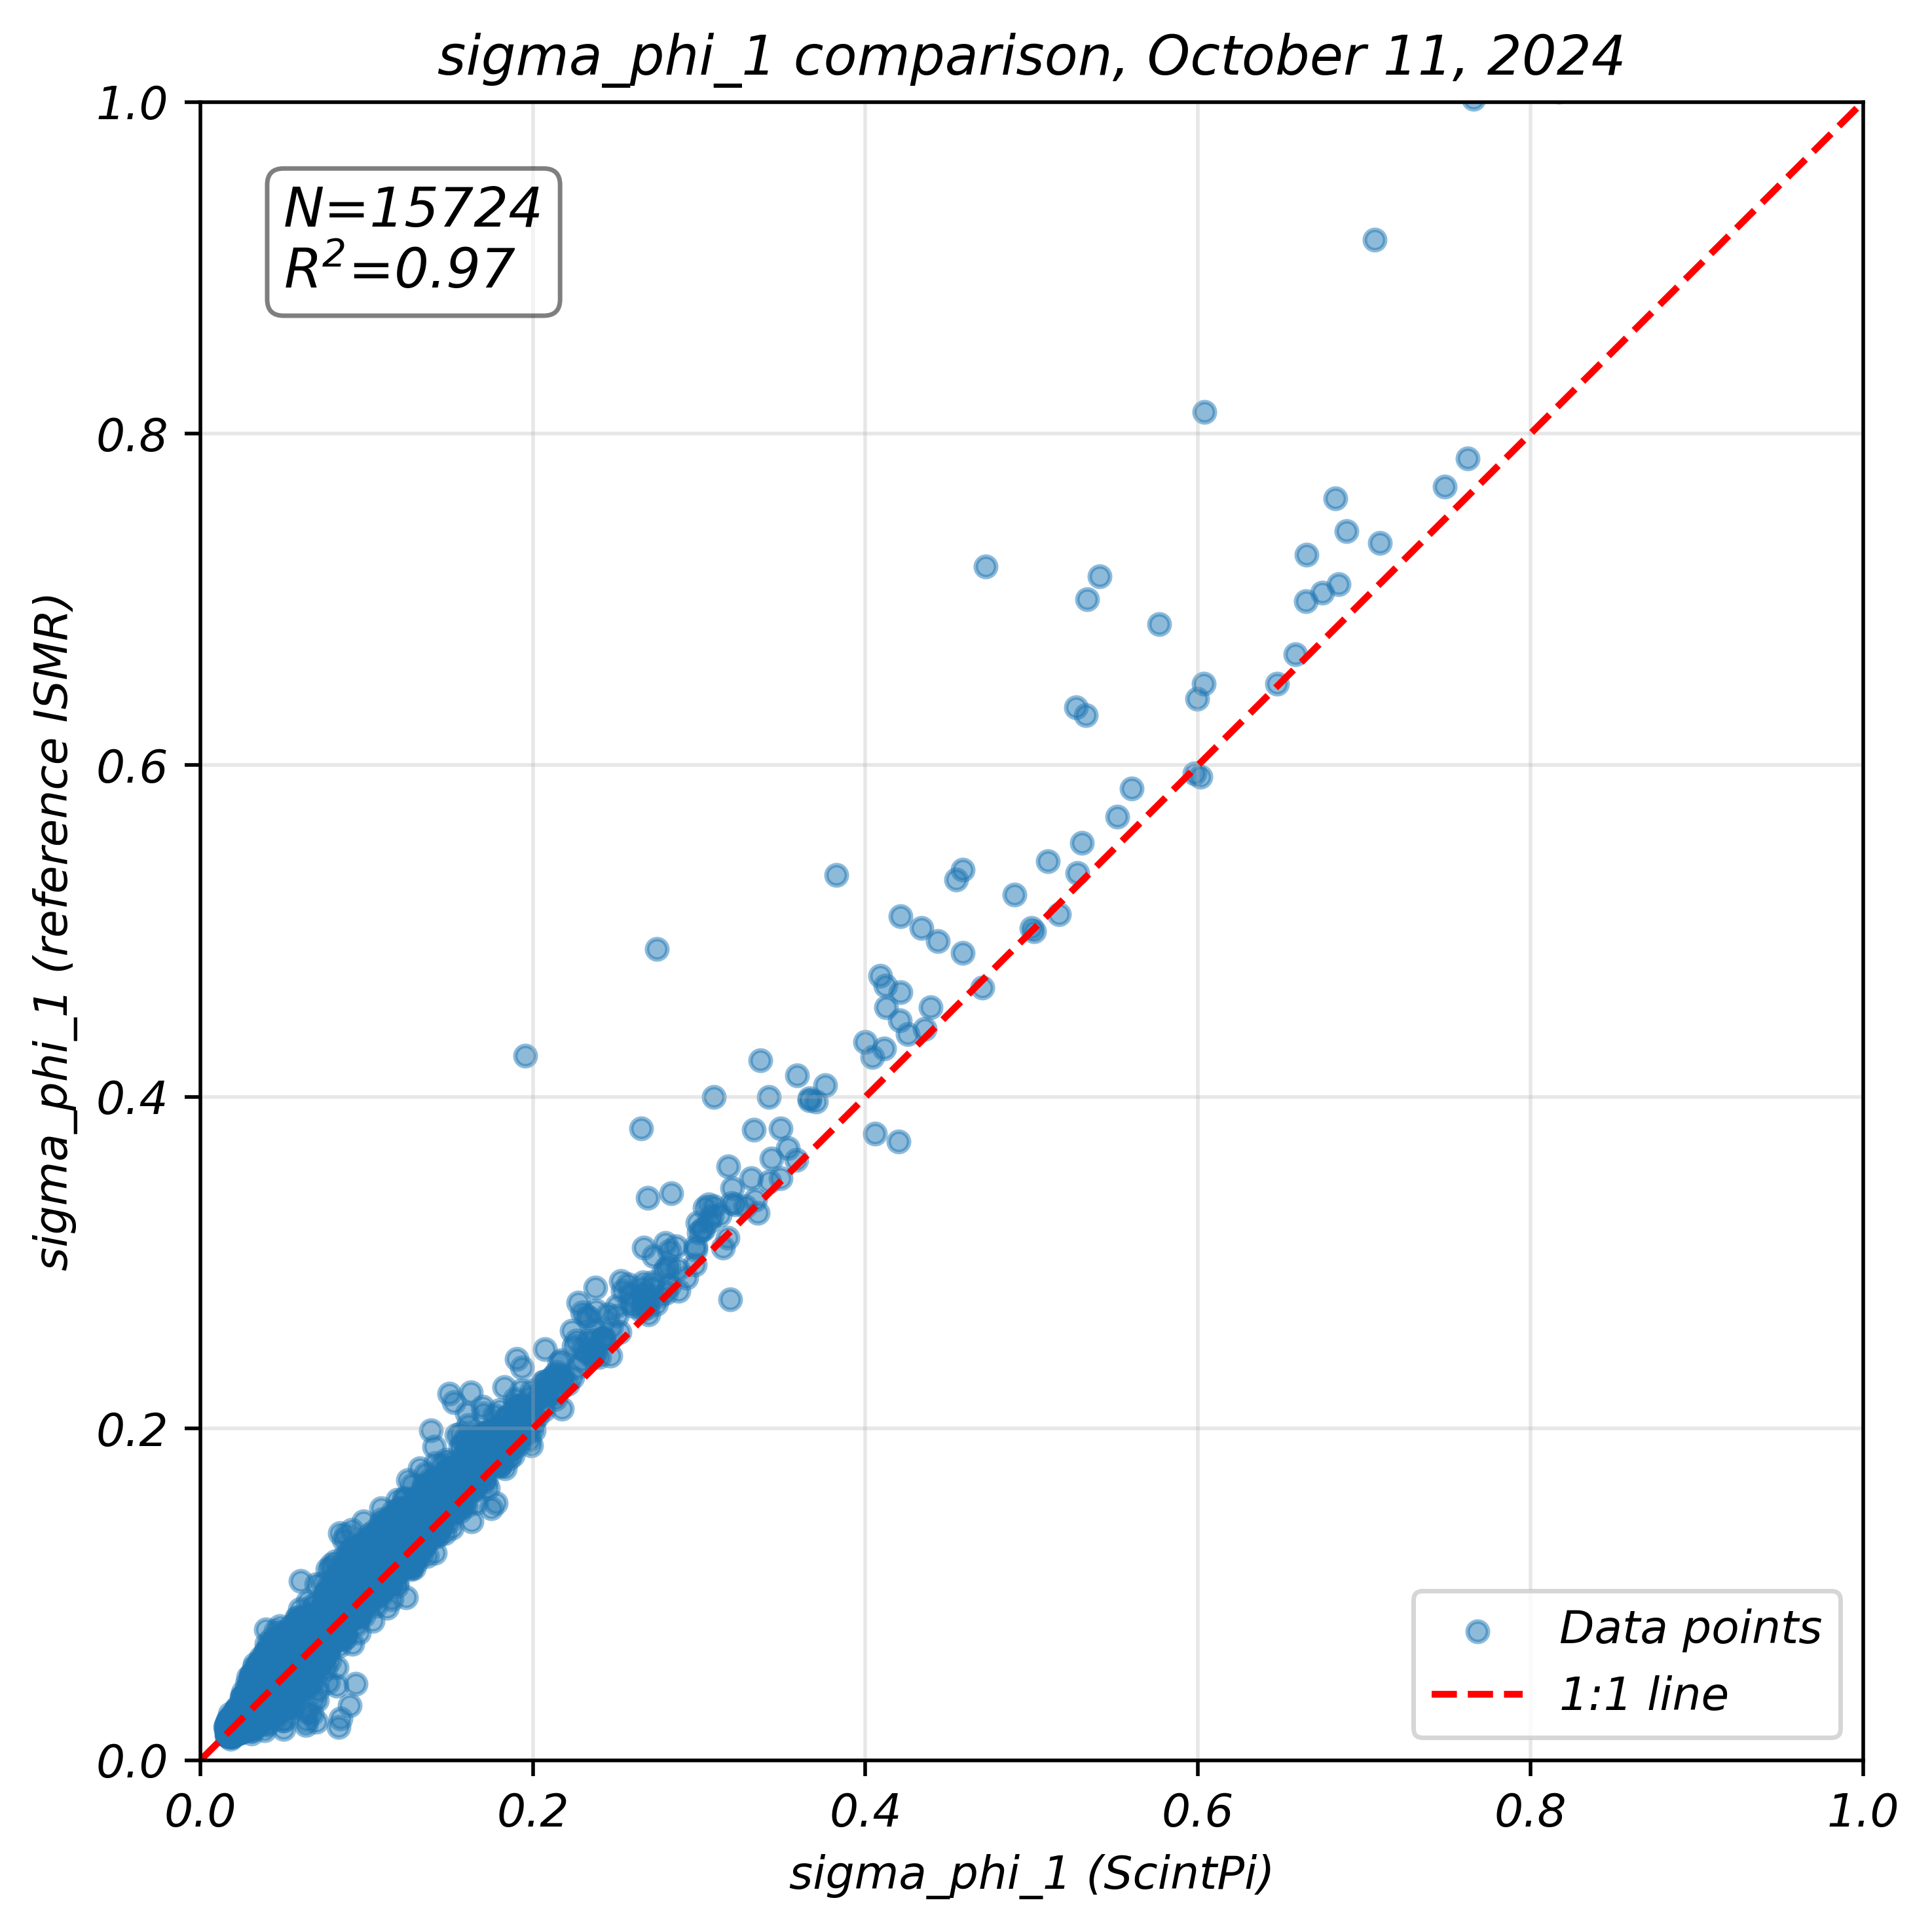

In [8]:
import matplotlib.pyplot as plt

x = comparison_df["sigma_phi_1"].to_numpy()
y = comparison_df["sigma_phi_1_ismr"].to_numpy()

ss_res = np.sum((y - x) ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)
r2 = 1 - (ss_res / ss_tot)
n = len(comparison_df)
max_val = max(np.nanmax(x), np.nanmax(y))

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x, y, alpha=0.5, s=20, c="tab:blue", label="Data points")
ax.plot([0, max_val], [0, max_val], "r--", alpha=1, label="1:1 line")
ax.text(
    0.05,
    0.95,
    f"N={n}\n$R^2$={r2:.2f}",
    transform=ax.transAxes,
    va="top",
    fontsize=12,
    bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.5},
)
ax.set(
    xlabel="sigma_phi_1 (ScintPi)",
    ylabel="sigma_phi_1 (reference ISMR)",
    xlim=(0, 1),
    ylim=(0, 1),
    title="sigma_phi_1 comparison, October 11, 2024",
)
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()